# Baja Data Analysis - Accelerometer (ADXL 326)

There are a total of 5 channels measruring acceleration: <strong>CH1-CH5</strong>
Currently, the file will measure:
<ul>
    <li>Acceleration of CH1, CH2, CH3</li>
    <li>Acceleration of CH4, CH5</li>
    <li>Voltage of CH1, CH2, CH3</li>
    <li>Voltage of CH4, CH5</li>
    <li>Max, min acceleration + voltage</li>
<ul>

#### Corrupted - error data part eliminated not to use

<img src="images/corrupted part.png" width="40%">

Importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

ALL DATA IS BELOW

In [5]:
# All the data type of float64
accelerometer_df = pd.read_csv("data/Hat1_Accelerometer_Acquisition1_09-10-2026.csv", 
    dtype={
        "elapsed_s": "float64",
        "CH1_voltage_V": "float64",
        "CH1_accel_x_ms2": "float64",
        "CH2_voltage_V": "float64",
        "CH2_accel_x_ms2": "float64",
        "CH3_voltage_V": "float64",
        "CH3_accel_x_ms2": "float64",
        "CH4_voltage_V": "float64",
        "CH4_accel_x_ms2": "float64",
        "CH5_voltage_V": "float64",
        "CH5_accel_x_ms2": "float64",
    })
accelerometer_df

slicing_corrupted = 641479

### ACCELERATION RANGE

In [6]:
slicing_corrupted = 641479
slicing_acceleration_df = accelerometer_df.iloc[0:slicing_corrupted]
for channel in range (1, 6):
    name = "CH" + str(channel) + "_accel_x_ms2"
    print(f"Acceleration range of channel {channel}: [{slicing_acceleration_df[name].min()}, {slicing_acceleration_df[name].max()}]")

Acceleration range of channel 1: [-30.402191, 31.949818]
Acceleration range of channel 2: [-27.739632, 35.144878]
Acceleration range of channel 3: [-38.486641, 50.248775]
Acceleration range of channel 4: [-191.994568, -139.808655]
Acceleration range of channel 5: [-203.467728, -144.98851]


### VOLTAGE RANGE

In [7]:
slicing_voltage_df = accelerometer_df.iloc[0:slicing_corrupted]
for channel in range (1, 6):
    name = "CH" + str(channel) + "_voltage_V"
    print(f"Voltage range of channel {channel}: [{slicing_voltage_df[name].min()}, {slicing_voltage_df[name].max()}]")

Voltage range of channel 1: [1.44374, 1.841123]
Voltage range of channel 2: [1.460709, 1.861486]
Voltage range of channel 3: [1.392216, 1.957747]
Voltage range of channel 4: [0.413875, 0.746468]
Voltage range of channel 5: [0.340754, 0.713455]


In [8]:
slicing_acceleration_df = accelerometer_df.iloc[0:slicing_corrupted]
for channel in range (1, 6):
    name = "CH" + str(channel) + "_voltage_V"
    print(f"Acceleration range of channel {channel}: [{slicing_acceleration_df[name].min()}, {slicing_acceleration_df[name].max()}]")

Acceleration range of channel 1: [1.44374, 1.841123]
Acceleration range of channel 2: [1.460709, 1.861486]
Acceleration range of channel 3: [1.392216, 1.957747]
Acceleration range of channel 4: [0.413875, 0.746468]
Acceleration range of channel 5: [0.340754, 0.713455]


# ACCELERATION

## CH1, CH2, CH3 ACCELERATION

### 1. MATPLOTLIB (FIXED)

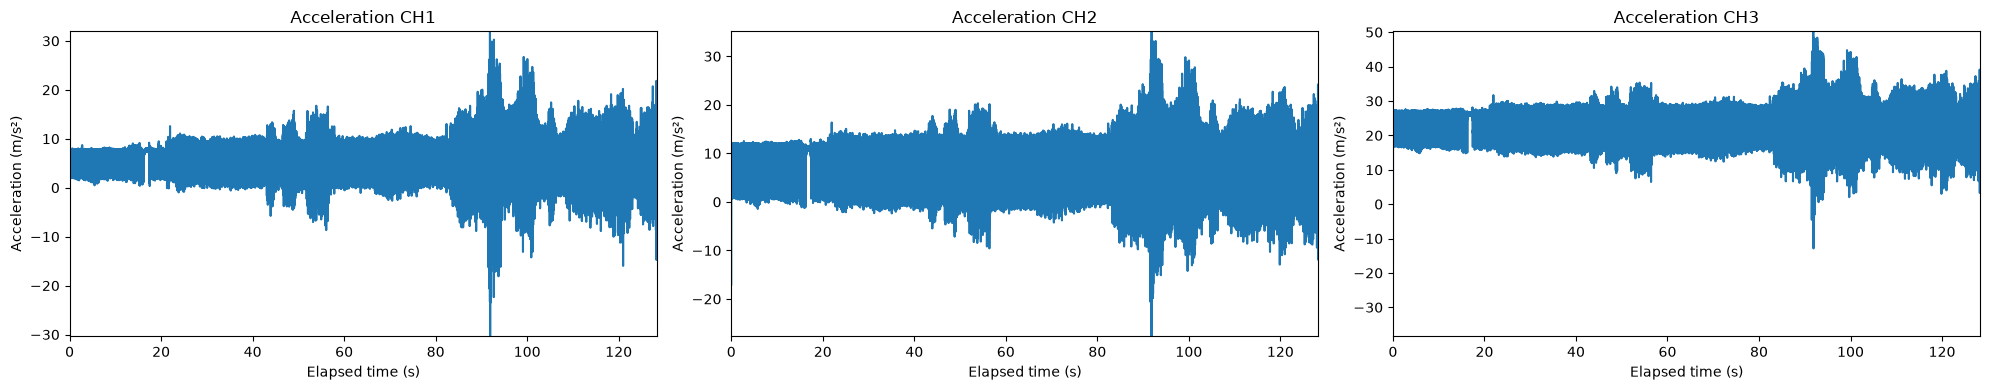

In [9]:
# filter corrupting data
data_x = accelerometer_df['elapsed_s'].iloc[0:slicing_corrupted]
data_y_1 = accelerometer_df['CH1_accel_x_ms2'].iloc[0:slicing_corrupted]
data_y_2 = accelerometer_df['CH2_accel_x_ms2'].iloc[0:slicing_corrupted]
data_y_3 = accelerometer_df['CH3_accel_x_ms2'].iloc[0:slicing_corrupted]

fig, ax = plt.subplots(1, 3, figsize=(20,4)) # 1 row 3 columns

ax[0].plot(data_x, data_y_1)
ax[0].set_title('Acceleration CH1')
# call x, y axis
ax[0].set_xlabel('Elapsed time (s)')
ax[0].set_ylabel('Acceleration (m/s²)')
# set limit for x,y axis
ax[0].set_xlim(data_x.min(), data_x.max())
ax[0].set_ylim(data_y_1.min(), data_y_1.max())

ax[1].plot(data_x, data_y_2)
ax[1].set_title('Acceleration CH2')
# call x, y axis
ax[1].set_xlabel('Elapsed time (s)')
ax[1].set_ylabel('Acceleration (m/s²)')
# set limit for x,y axis
ax[1].set_xlim(data_x.min(), data_x.max())
ax[1].set_ylim(data_y_2.min(), data_y_2.max())

ax[2].plot(data_x, data_y_3)
ax[2].set_title('Acceleration CH3')
# call x, y axis
ax[2].set_xlabel('Elapsed time (s)')
ax[2].set_ylabel('Acceleration (m/s²)')
# set limit for x,y axis
ax[2].set_xlim(data_x.min(), data_x.max())
ax[2].set_ylim(data_y_3.min(), data_y_3.max())

plt.tight_layout()
plt.show() # hide memory and object


### 2. PLOTLY (INTERACTIVE)

In [13]:
data = accelerometer_df.iloc[0:slicing_corrupted]

figure1 = px.line(
    data,
    x = 'elapsed_s', # name colum
    y = 'CH1_accel_x_ms2', # name column
    title = 'Acceleration CH1',
    labels={
        'elapsed_s': 'Elapsed time (s)',
        'CH1_accel_x_ms2': 'Acceleration (m/s²)'
    }
)

figure2 = px.line(
    data,
    x = 'elapsed_s', # name colum
    y = 'CH2_accel_x_ms2', # name column
    title = 'Acceleration CH2',
    labels={
        'elapsed_s': 'Elapsed time (s)',
        'CH2_accel_x_ms2': 'Acceleration (m/s²)'
    }
)

figure3 = px.line(
    data,
    x = 'elapsed_s', # name colum
    y = 'CH3_accel_x_ms2', # name column
    title = 'Acceleration CH3',
    labels={
        'elapsed_s': 'Elapsed time (s)',
        'CH3_accel_x_ms2': 'Acceleration (m/s²)'
    }
)

# initialize output

out1 = widgets.Output()
out2 = widgets.Output()
out3 = widgets.Output()

with out1:
    figure1.show()

with out2:
    figure2.show()

with out3:
    figure3.show()

display(widgets.HBox([out1, out2, out3]))

## CH4, CH5 ACCELERATION

### 1. MATPLOTLIB (FIXED)

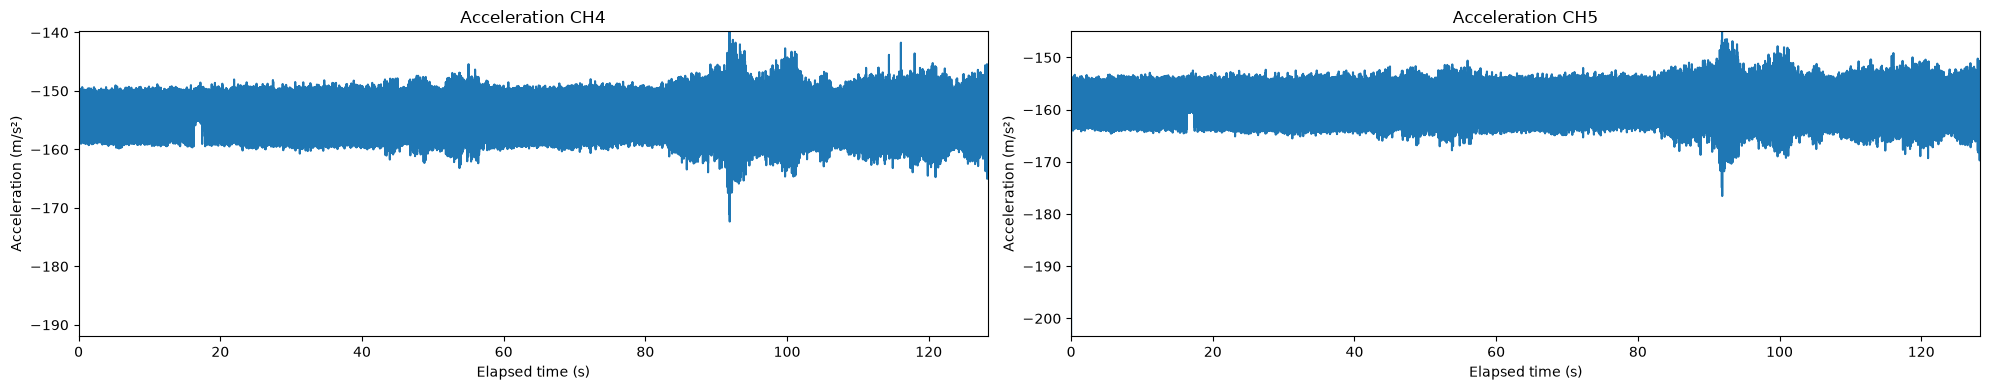

In [11]:
data_x_2 = accelerometer_df['elapsed_s'].iloc[0:slicing_corrupted]
data_y_4 = accelerometer_df['CH4_accel_x_ms2'].iloc[0:slicing_corrupted]
data_y_5 = accelerometer_df['CH5_accel_x_ms2'].iloc[0:slicing_corrupted]

fig, ax2 = plt.subplots(1, 2, figsize=(20, 4))

ax2[0].set_title('Acceleration CH4')
ax2[0].set_xlabel('Elapsed time (s)')
ax2[0].set_ylabel('Acceleration (m/s²)')
ax2[0].set_xlim(data_x_2.min(), data_x_2.max())
ax2[0].set_ylim(data_y_4.min(), data_y_4.max())
ax2[0].plot(data_x_2, data_y_4)

ax2[1].set_title('Acceleration CH5')
ax2[1].set_xlabel('Elapsed time (s)')
ax2[1].set_ylabel('Acceleration (m/s²)')
ax2[1].set_xlim(data_x_2.min(), data_x_2.max())
ax2[1].set_ylim(data_y_5.min(), data_y_5.max())
ax2[1].plot(data_x_2, data_y_5)

plt.tight_layout()
plt.show()


### 2. PLOTLY (INTERACTIVE)

In [12]:
figure4 = px.line(
    data,
    x = 'elapsed_s',
    y = 'CH4_accel_x_ms2',
    title = 'Acceleration CH4',
    labels = {
        'elapsed_s' : 'Elapsed time (s)',
        'CH4_accel_x_ms2': 'Acceleration (m/s²)'
    }
)

figure5 = px.line(
    data,
    x = 'elapsed_s',
    y = 'CH5_accel_x_ms2',
    title = 'Acceleration CH5',
    labels = {
        'elapsed_s' : 'Elapsed time (s)',
        'CH5_accel_x_ms2': 'Acceleration (m/s²)'
    }
)

# set ouput
out4 = widgets.Output()
out5 = widgets.Output()

with out4:
    figure4.show()

with out5:
    figure5.show()

display(widgets.HBox([out4, out5]))

# VOLTAGE

## CH1, CH2, CH3 VOLTAGE

### 1. MATPLOTLIB (FIXED)

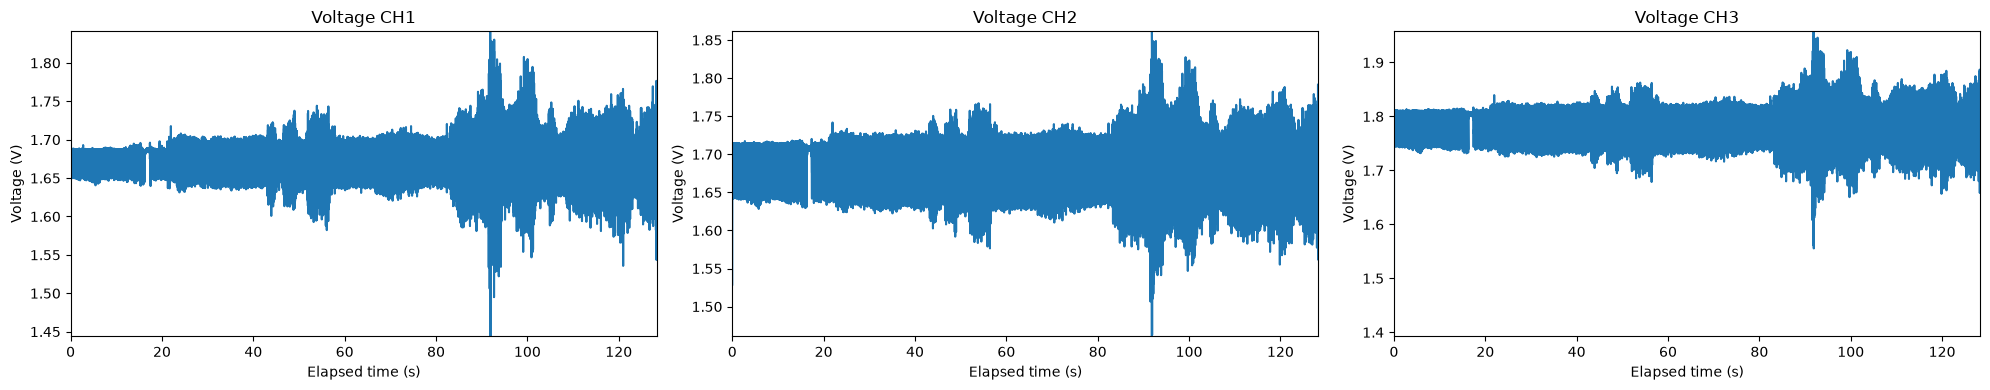

In [15]:
data_x_3 = accelerometer_df['elapsed_s'].iloc[0:slicing_corrupted]
data_y_1_2 = accelerometer_df['CH1_voltage_V'].iloc[0:slicing_corrupted]
data_y_2_2 = accelerometer_df['CH2_voltage_V'].iloc[0:slicing_corrupted]
data_y_3_2 = accelerometer_df['CH3_voltage_V'].iloc[0:slicing_corrupted]

fig, ax3 = plt.subplots(1, 3, figsize=(20, 4))

ax3[0].set_title('Voltage CH1')
ax3[0].set_xlim(data_x_3.min(), data_x_3.max())
ax3[0].set_ylim(data_y_1_2.min(), data_y_1_2.max())
ax3[0].set_xlabel('Elapsed time (s)')
ax3[0].set_ylabel('Voltage (V)')
ax3[0].plot(data_x_3, data_y_1_2)

ax3[1].set_title('Voltage CH2')
ax3[1].set_xlim(data_x_3.min(), data_x_3.max())
ax3[1].set_ylim(data_y_2_2.min(), data_y_2_2.max())
ax3[1].set_xlabel('Elapsed time (s)')
ax3[1].set_ylabel('Voltage (V)')
ax3[1].plot(data_x_3, data_y_2_2)

ax3[2].set_title('Voltage CH3')
ax3[2].set_xlim(data_x_3.min(), data_x_3.max())
ax3[2].set_ylim(data_y_3_2.min(), data_y_3_2.max())
ax3[2].set_xlabel('Elapsed time (s)')
ax3[2].set_ylabel('Voltage (V)')
ax3[2].plot(data_x_3, data_y_3_2)

plt.tight_layout()
plt.show()

### 2. PLOTLY (INTERACTIVE)

In [17]:
figure1_2 = px.line(
    data,
    x = 'elapsed_s',
    y = 'CH1_voltage_V',
    title = 'Voltage CH1',
    labels={
        'elapsed_s' : 'Elapsed time (s)',
        'CH1_voltage_V' : 'Voltage (V)'
    }
)

figure2_2 = px.line(
    data,
    x = 'elapsed_s',
    y = 'CH2_voltage_V',
    title = 'Voltage CH2',
    labels={
        'elapsed_s' : 'Elapsed time (s)',
        'CH2_voltage_V' : 'Voltage (V)'
    }
)

figure3_2 = px.line(
    data,
    x = 'elapsed_s',
    y = 'CH3_voltage_V',
    title = 'Voltage CH3',
    labels={
        'elapsed_s' : 'Elapsed time (s)',
        'CH3_voltage_V' : 'Voltage (V)'
    }
)

out1_2 = widgets.Output()
out2_2 = widgets.Output()
out3_2 = widgets.Output()

with out1_2:
    figure1_2.show()

with out2_2:
    figure2_2.show()

with out3_2:
    figure3_2.show()

display(widgets.HBox([out1_2, out2_2, out3_2]))

## CH4, CH5 VOLTAGE

### 1. MATPLOTLIB (FIXED)

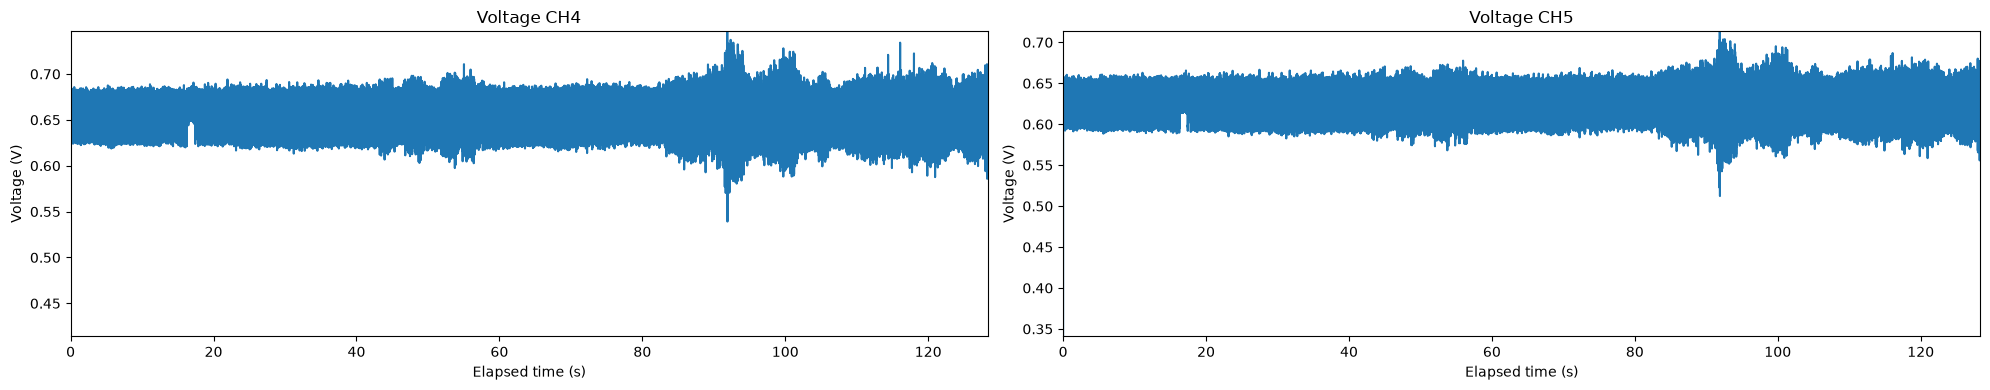

In [19]:
data_x_4 = accelerometer_df['elapsed_s'].iloc[0:slicing_corrupted]
data_y_4_2 = accelerometer_df['CH4_voltage_V'].iloc[0:slicing_corrupted]
data_y_5_2 = accelerometer_df['CH5_voltage_V'].iloc[0:slicing_corrupted]

fig, ax4 = plt.subplots(1, 2, figsize=(20, 4))

ax4[0].set_title('Voltage CH4')
ax4[0].set_xlim(data_x_4.min(), data_x_4.max())
ax4[0].set_ylim(data_y_4_2.min(), data_y_4_2.max())
ax4[0].set_xlabel('Elapsed time (s)')
ax4[0].set_ylabel('Voltage (V)')
ax4[0].plot(data_x_4, data_y_4_2)

ax4[1].set_title('Voltage CH5')
ax4[1].set_xlim(data_x_4.min(), data_x_4.max())
ax4[1].set_ylim(data_y_5_2.min(), data_y_5_2.max())
ax4[1].set_xlabel('Elapsed time (s)')
ax4[1].set_ylabel('Voltage (V)')
ax4[1].plot(data_x_4, data_y_5_2)

plt.tight_layout()
plt.show()

### 2. PLOTLY (INTERACTIVE)

In [20]:
figure4_2 = px.line(
    data,
    x = 'elapsed_s',
    y = 'CH4_voltage_V',
    title = 'Voltage CH4',
    labels={
        'elapsed_s' : 'Elapsed time (s)',
        'CH4_voltage_V' : 'Voltage (V)'
    }
)

figure5_2 = px.line(
    data,
    x = 'elapsed_s',
    y = 'CH5_voltage_V',
    title = 'Voltage CH5',
    labels={
        'elapsed_s' : 'Elapsed time (s)',
        'CH4_voltage_V' : 'Voltage (V)'
    }
)

out4_2 = widgets.Output()
out5_2 = widgets.Output()

with out4_2:
    figure4_2.show()

with out5_2:
    figure5_2.show()

display(widgets.HBox([out4_2, out5_2]))